# Imputation Ablation Study

How does restricting to sites with low imputation rates affect model rankings and scores?

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams.update({"font.size": 12, "figure.dpi": 120})

ABLATION_DIR = Path("imputation_ablation")
BASELINE_DIR = Path("output/leaderboard")
THRESHOLDS = [5, 10, 15, 20, 30]

# Load all leaderboards
dfs = {}
for t in THRESHOLDS:
    path = ABLATION_DIR / f"results_lt_{t}pct" / "pollutant_balanced_leaderboard.csv"
    dfs[t] = pd.read_csv(path)

# Baseline (no imputation filtering)
dfs["all"] = pd.read_csv(BASELINE_DIR / "pollutant_balanced_leaderboard.csv")

# Site counts per threshold per dataset
site_counts = {}
for t in THRESHOLDS:
    site_counts[t] = {}
    for ds_dir in ABLATION_DIR.iterdir():
        if not ds_dir.is_dir() or ds_dir.name.startswith("results"):
            continue
        csv = ds_dir / f"lt_{t}pct.csv"
        if csv.exists():
            site_counts[t][ds_dir.name] = len(pd.read_csv(csv))

print("Loaded leaderboards for thresholds:", list(dfs.keys()))

Loaded leaderboards for thresholds: [5, 10, 15, 20, 30, 'all']


## 1. Overall Leaderboard: MASE across thresholds

In [56]:
# Build a combined table: model x threshold -> MASE
labels = [f"<{t}%" for t in THRESHOLDS] + ["All"]
keys = THRESHOLDS + ["all"]

records = []
for key, label in zip(keys, labels):
    for _, row in dfs[key].iterrows():
        records.append({"model": row["model"], "threshold": label, "MASE": row["MASE (norm.)"], "CRPS": row["CRPS (norm.)"]})

combined = pd.DataFrame(records)

# Pivot for MASE
pivot_mase = combined.pivot(index="model", columns="threshold", values="MASE")[labels]
pivot_mase = pivot_mase.sort_values("All")
pivot_mase.round(4)

threshold,<5%,<10%,<15%,<20%,<30%,All
model,,,,,,
visiontspp_base,0.7699,0.7718,0.7734,0.7795,0.7785,0.7785
TiRex,0.7743,0.7753,0.7771,0.7834,0.7825,0.7825
TimesFM-2.5,0.7757,0.7766,0.7782,0.7842,0.7831,0.7831
moirai2,0.7851,0.7865,0.7874,0.7927,0.7916,0.7916
chronos2_base,0.7867,0.7856,0.7872,0.7937,0.7929,0.7929
chronos_bolt_base,0.7917,0.7905,0.7919,0.7982,0.7976,0.7976
sundial_base,0.7918,0.7931,0.7936,0.7988,0.7977,0.7977
TimesFM-2.0,0.7962,0.7970,0.7982,0.8021,0.8013,0.8013
moirai_base,0.8051,0.8063,0.8064,0.8116,0.8103,0.8103


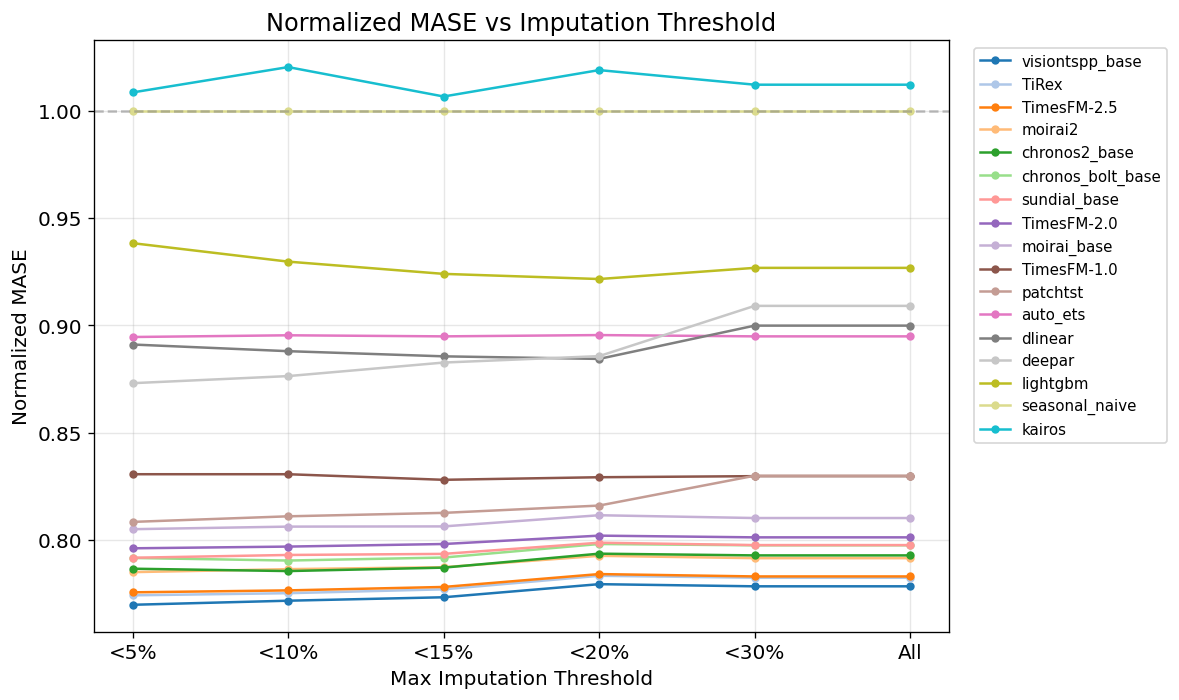

In [57]:
# Line plot: MASE(norm.) vs threshold for each model
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = list(range(len(labels)))
models_sorted = pivot_mase.index.tolist()

cmap = plt.cm.tab20
for i, model in enumerate(models_sorted):
    vals = pivot_mase.loc[model].values
    ax.plot(x_pos, vals, marker="o", label=model, color=cmap(i / len(models_sorted)), linewidth=1.5, markersize=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel("Max Imputation Threshold")
ax.set_ylabel("Normalized MASE")
ax.set_title("Normalized MASE vs Imputation Threshold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Seasonal Naive")
plt.tight_layout()
plt.savefig(ABLATION_DIR / "mase_vs_threshold.pdf", bbox_inches="tight")
plt.show()

## 2. Rank Stability

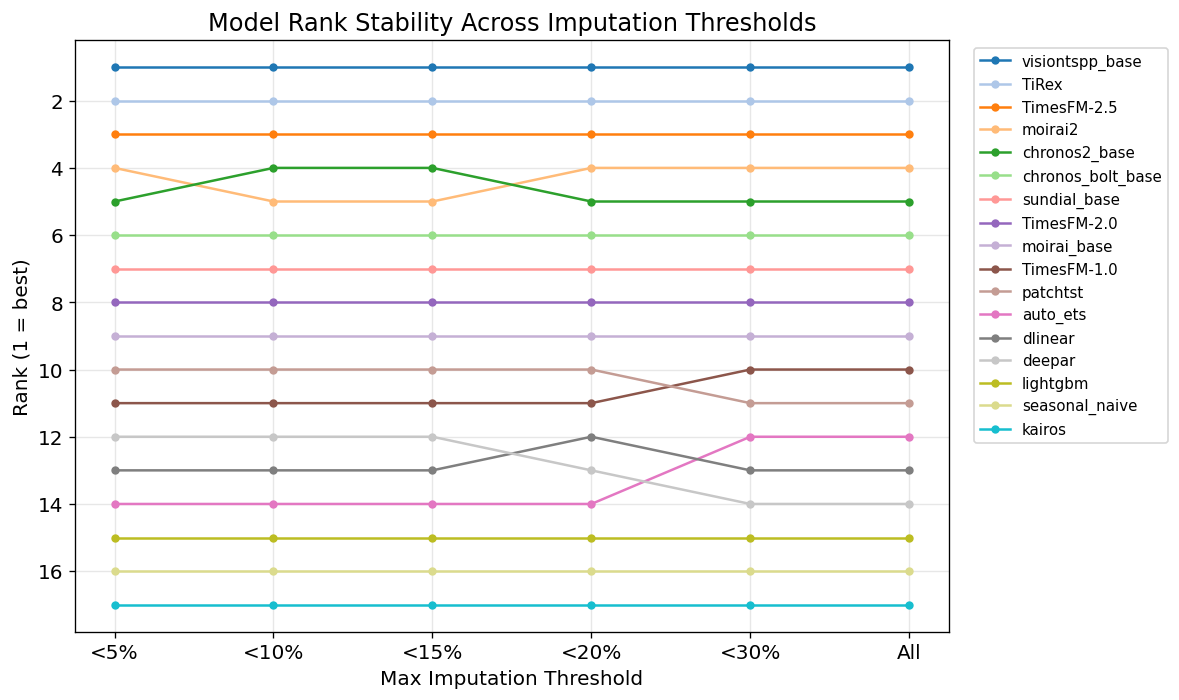

In [58]:
# Rank each model at each threshold
rank_df = pivot_mase.rank(axis=0, method="min")

fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models_sorted):
    ranks = rank_df.loc[model].values
    ax.plot(x_pos, ranks, marker="o", label=model, color=cmap(i / len(models_sorted)), linewidth=1.5, markersize=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel("Max Imputation Threshold")
ax.set_ylabel("Rank (1 = best)")
ax.set_title("Model Rank Stability Across Imputation Thresholds")
ax.invert_yaxis()
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ABLATION_DIR / "rank_stability.pdf", bbox_inches="tight")
plt.show()

## 3. MASE Change Relative to Baseline (All Sites)

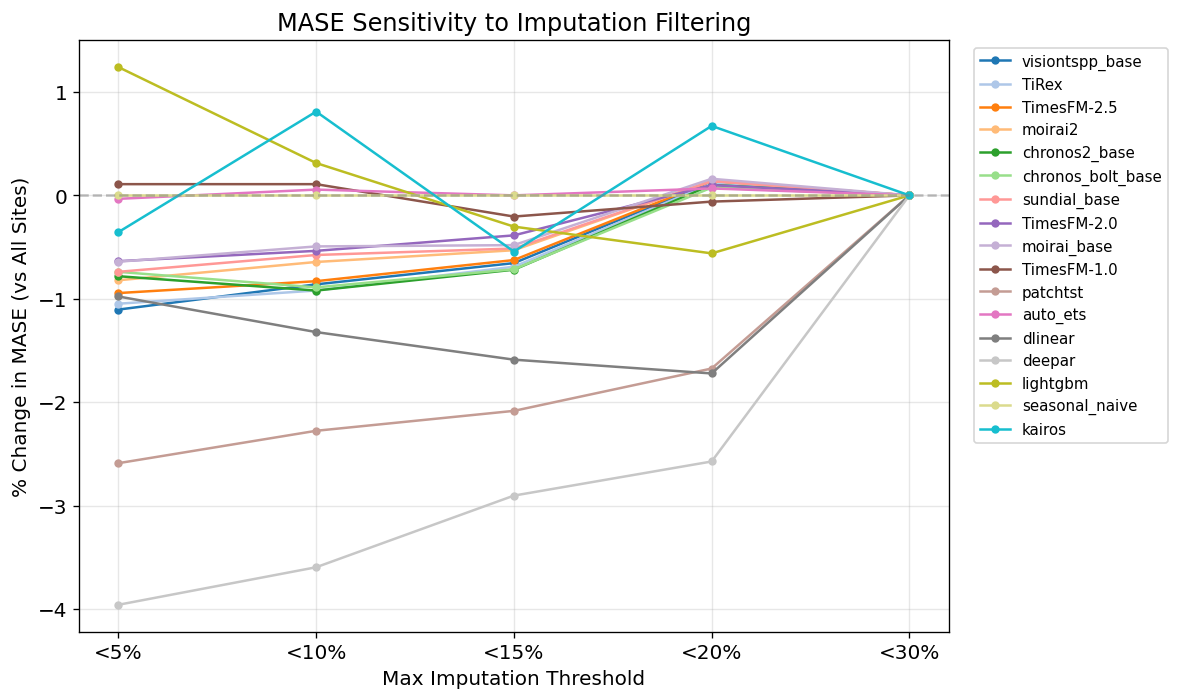

In [59]:
# % change in MASE from baseline (all sites) at each threshold
baseline_mase = pivot_mase["All"]
pct_change = pivot_mase.drop(columns="All").subtract(baseline_mase, axis=0).divide(baseline_mase, axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
threshold_labels = [f"<{t}%" for t in THRESHOLDS]
x_pos_t = list(range(len(threshold_labels)))

for i, model in enumerate(models_sorted):
    vals = pct_change.loc[model].values
    ax.plot(x_pos_t, vals, marker="o", label=model, color=cmap(i / len(models_sorted)), linewidth=1.5, markersize=4)

ax.set_xticks(x_pos_t)
ax.set_xticklabels(threshold_labels)
ax.set_xlabel("Max Imputation Threshold")
ax.set_ylabel("% Change in MASE (vs All Sites)")
ax.set_title("MASE Sensitivity to Imputation Filtering")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ABLATION_DIR / "mase_pct_change.pdf", bbox_inches="tight")
plt.show()